In [7]:
import pandas as pd
import numpy as np

### 1. Connect to Google Drive and Load Data

First, I will connect to Google Drive to access the dataset and load the `transactions_2026-04-29_07-47-39_1.csv` file, selecting only the specified columns.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import zipfile

# List of columns to load
columns_to_load = [
    'instance_date',
    'trans_group_en',
    'procedure_name_en',
    'property_type_en',
    'property_sub_type_en',
    'property_usage_en',
    'reg_type_en',
    'area_name_en',
    'building_name_en',
    'master_project_en',
    'nearest_landmark_en',
    'nearest_metro_en',
    'nearest_mall_en',
    'rooms_en',
    'has_parking',
    'procedure_area',
    'actual_worth',
    'meter_sale_price',
    'no_of_parties_role_1',
    'no_of_parties_role_2',
    'no_of_parties_role_3',
    'area_id'
]

# Define paths for transactions zip file
zip_file_path_transactions = '/content/drive/MyDrive/dataset/transactions_raw.csv.zip'
csv_file_in_zip_transactions = 'transactions_2026-04-29_07-47-39_1.csv' # Assuming this is the correct name inside the zip

with zipfile.ZipFile(zip_file_path_transactions, 'r') as zf:
    with zf.open(csv_file_in_zip_transactions) as file_handle:
        df = pd.read_csv(file_handle, usecols=columns_to_load)

display(df.head())

,trans_group_en,procedure_name_en,instance_date,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_id,area_name_en,building_name_en,...,nearest_metro_en,nearest_mall_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,Sales,Sell - Pre registration,2015-10-20,Unit,Flat,Residential,Off-Plan Properties,442,Al Barsha South Fifth,EDMONTON ELM,...,Damac Properties,Marina Mall,Studio,1,60.90,560975.0,9211.43,1.0,1.0,0.0
1,Sales,Lease to Own Registration,2019-11-06,Unit,Flat,Residential,Existing Properties,464,Wadi Al Safa 2,MAZAYA 6,...,NaN,NaN,2 B/R,1,151.59,805000.0,5310.38,2.0,2.0,2.0
2,Gifts,Grant,2025-04-14,Unit,Flat,Residential,Existing Properties,334,Al Jadaf,Binghatti Avenue,...,Healthcare City Metro Station,Dubai Mall,1 B/R,1,17.59,227966.0,12960.00,1.0,3.0,0.0
3,Sales,Sell - Pre registration,2024-12-19,Unit,Flat,Residential,Off-Plan Properties,330,Marsa Dubai,SOBHA SEAHAVEN - TOWER C,...,NaN,NaN,2 B/R,1,156.27,6896528.0,44132.13,1.0,1.0,0.0
4,Sales,Sell - Pre registration,2017-05-08,Unit,Flat,Residential,Off-Plan Properties,334,Al Jadaf,DUBAI WHARF TOWER 2,...,Al Jadaf Metro Station,Dubai Mall,Studio,1,61.60,947000.0,15373.38,1.0,1.0,0.0


### 2. Extract Year and Month from `instance_date`

Now, I will extract the year and month from the `instance_date` column and then remove the original `instance_date` column.

In [9]:
df['instance_date'] = pd.to_datetime(df['instance_date'], errors='coerce')
df['year'] = df['instance_date'].dt.year
df['month'] = df['instance_date'].dt.month
df = df.drop(columns=['instance_date'])
display(df.head())

,trans_group_en,procedure_name_en,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_id,area_name_en,building_name_en,master_project_en,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,year,month
0,Sales,Sell - Pre registration,Unit,Flat,Residential,Off-Plan Properties,442,Al Barsha South Fifth,EDMONTON ELM,Jumeirah Village Triangle,...,Studio,1,60.90,560975.0,9211.43,1.0,1.0,0.0,2015.0,10.0
1,Sales,Lease to Own Registration,Unit,Flat,Residential,Existing Properties,464,Wadi Al Safa 2,MAZAYA 6,Liwan1,...,2 B/R,1,151.59,805000.0,5310.38,2.0,2.0,2.0,2019.0,11.0
2,Gifts,Grant,Unit,Flat,Residential,Existing Properties,334,Al Jadaf,Binghatti Avenue,Dubai Health Care City Phase 2,...,1 B/R,1,17.59,227966.0,12960.00,1.0,3.0,0.0,2025.0,4.0
3,Sales,Sell - Pre registration,Unit,Flat,Residential,Off-Plan Properties,330,Marsa Dubai,SOBHA SEAHAVEN - TOWER C,Dubai Harbour,...,2 B/R,1,156.27,6896528.0,44132.13,1.0,1.0,0.0,2024.0,12.0
4,Sales,Sell - Pre registration,Unit,Flat,Residential,Off-Plan Properties,334,Al Jadaf,DUBAI WHARF TOWER 2,Jaddaf Waterfront,...,Studio,1,61.60,947000.0,15373.38,1.0,1.0,0.0,2017.0,5.0


### 3. Deal with Null Values

I will first inspect the null values, then fill categorical missing values with 'Unknown' and numerical missing values with the median of their respective columns.

In [10]:
print('Null values before imputation:')
display(df.isnull().sum()[df.isnull().sum() > 0])

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Fill categorical nulls with 'Unknown'
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# Fill numerical nulls with the median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print('\nNull values after imputation:')
display(df.isnull().sum()[df.isnull().sum() > 0])

Null values before imputation:


,0
property_sub_type_en,338694
property_usage_en,1
building_name_en,486931
master_project_en,231122
nearest_landmark_en,333989
nearest_metro_en,519205
nearest_mall_en,529329
rooms_en,363017
no_of_parties_role_1,969
no_of_parties_role_2,969



Null values after imputation:


,0


### 4. Label Encode Categorical Columns

Now, I will apply Label Encoding to convert all categorical features into numerical representations.

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# If they are not, this block will need adjustment or those cells should be run first
file_path = '../data/transactions_2026-04-29_07-47-39_1.csv'
columns_to_load = [
    'instance_date',
    'trans_group_en',
    'procedure_name_en',
    'property_type_en',
    'property_sub_type_en',
    'property_usage_en',
    'reg_type_en',
    'area_name_en',
    'building_name_en',
    'master_project_en',
    'nearest_landmark_en',
    'nearest_metro_en',
    'nearest_mall_en',
    'rooms_en',
    'has_parking',
    'procedure_area',
    'actual_worth',
    'meter_sale_price',
    'no_of_parties_role_1',
    'no_of_parties_role_2',
    'no_of_parties_role_3',
    'area_id'
]

if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' was not found, reloading from CSV.")
    df = pd.read_csv(file_path, usecols=columns_to_load)

# Re-identify categorical columns after null imputation
categorical_cols = df.select_dtypes(include=['object']).columns

# Exclude 'area_name_en' from label encoding
categorical_cols = [col for col in categorical_cols if col != 'area_name_en']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f'Column \'{col}\' encoded. Unique values: {len(le.classes_)}')

display(df.head())

Column 'trans_group_en' encoded. Unique values: 3
Column 'procedure_name_en' encoded. Unique values: 52
Column 'property_type_en' encoded. Unique values: 4
Column 'property_sub_type_en' encoded. Unique values: 20
Column 'property_usage_en' encoded. Unique values: 12
Column 'reg_type_en' encoded. Unique values: 2
Column 'building_name_en' encoded. Unique values: 4859
Column 'master_project_en' encoded. Unique values: 175
Column 'nearest_landmark_en' encoded. Unique values: 15
Column 'nearest_metro_en' encoded. Unique values: 57
Column 'nearest_mall_en' encoded. Unique values: 6
Column 'rooms_en' encoded. Unique values: 18


,trans_group_en,procedure_name_en,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_id,area_name_en,building_name_en,master_project_en,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,year,month
0,2,48,2,2,8,1,442,Al Barsha South Fifth,1653,97,...,16,1,60.90,560975.0,9211.43,1.0,1.0,0.0,2015.0,10.0
1,2,24,2,2,8,0,464,Wadi Al Safa 2,2641,112,...,2,1,151.59,805000.0,5310.38,2.0,2.0,2.0,2019.0,11.0
2,0,15,2,2,8,0,334,Al Jadaf,922,54,...,0,1,17.59,227966.0,12960.00,1.0,3.0,0.0,2025.0,4.0
3,2,48,2,2,8,1,330,Marsa Dubai,3642,52,...,2,1,156.27,6896528.0,44132.13,1.0,1.0,0.0,2024.0,12.0
4,2,48,2,2,8,1,334,Al Jadaf,1566,89,...,16,1,61.60,947000.0,15373.38,1.0,1.0,0.0,2017.0,5.0


### 5. Check for `area_id` and change dtype

I will check for the presence of the `area_id` column. If it exists, I'll change its data type to float. If not, I'll inform you.

In [12]:
if 'area_id' in df.columns:
    df['area_id'] = df['area_id'].astype(float)
    print("Column 'area_id' successfully converted to float.")
else:
    print("The column 'area_id' was not found in the DataFrame. Please specify how you'd like to create or obtain this column if it's needed for further steps, especially for step 8 (aggregation by area_id).")
display(df.info())

Column 'area_id' successfully converted to float.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1697782 entries, 0 to 1697781
Data columns (total 23 columns):
 #   Column                Dtype  
---  ------                -----  
 0   trans_group_en        int64  
 1   procedure_name_en     int64  
 2   property_type_en      int64  
 3   property_sub_type_en  int64  
 4   property_usage_en     int64  
 5   reg_type_en           int64  
 6   area_id               float64
 7   area_name_en          object 
 8   building_name_en      int64  
 9   master_project_en     int64  
 10  nearest_landmark_en   int64  
 11  nearest_metro_en      int64  
 12  nearest_mall_en       int64  
 13  rooms_en              int64  
 14  has_parking           int64  
 15  procedure_area        float64
 16  actual_worth          float64
 17  meter_sale_price      float64
 18  no_of_parties_role_1  float64
 19  no_of_parties_role_2  float64
 20  no_of_parties_role_3  float64
 21  year                  float

None

### 6. Checking for Outliers

I will generate box plots for all numerical columns to visualize and identify potential outliers.

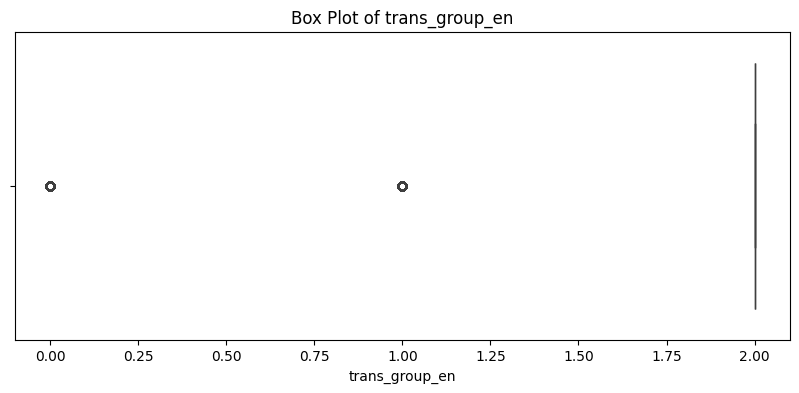

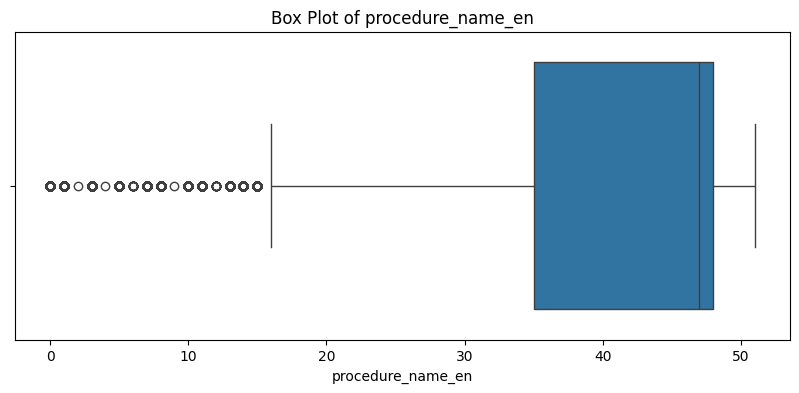

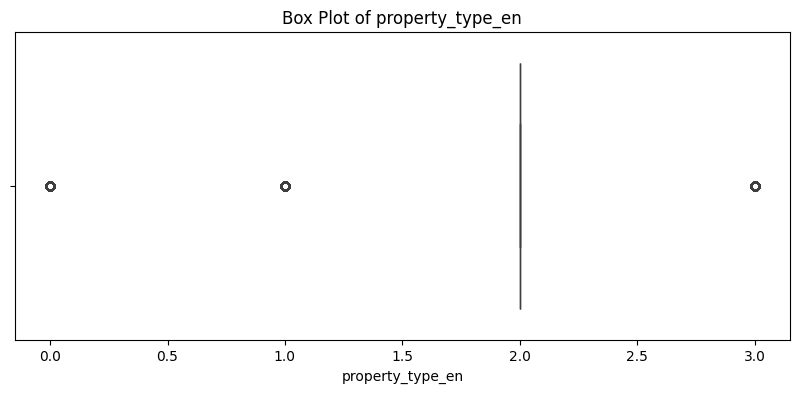

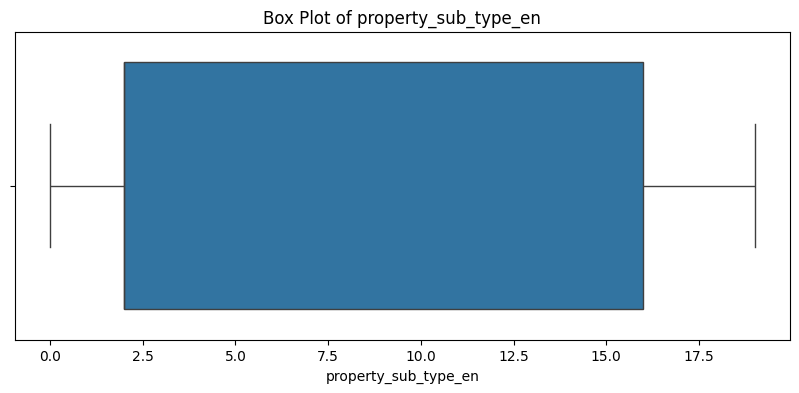

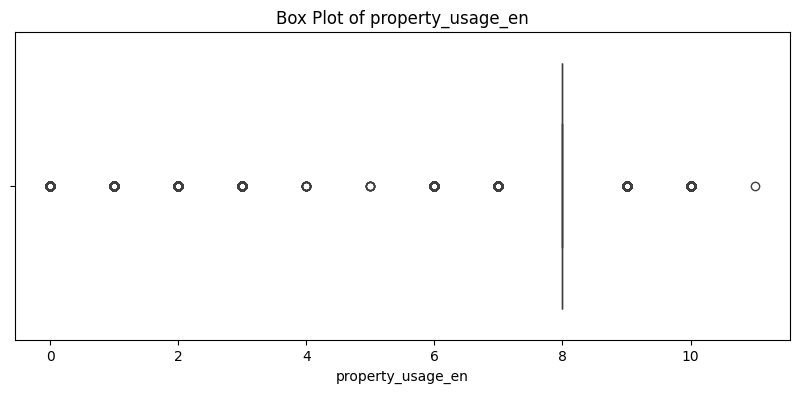

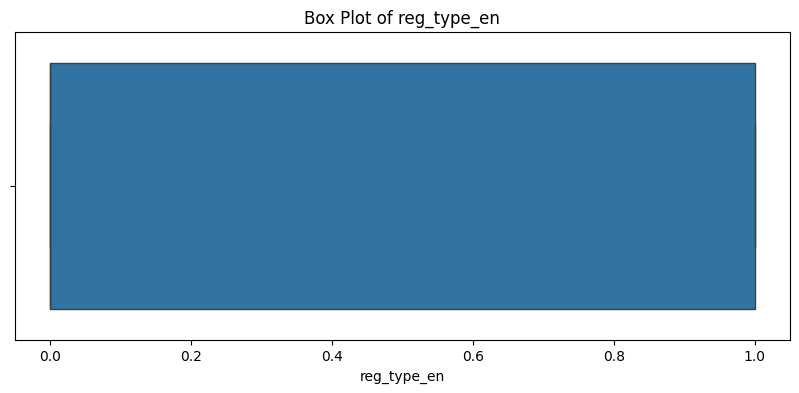

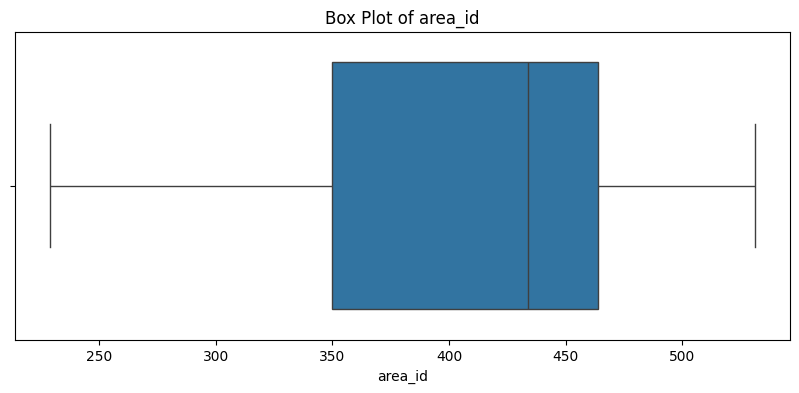

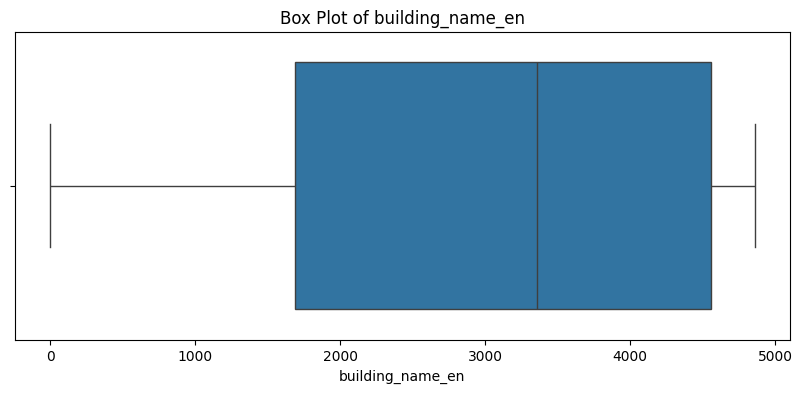

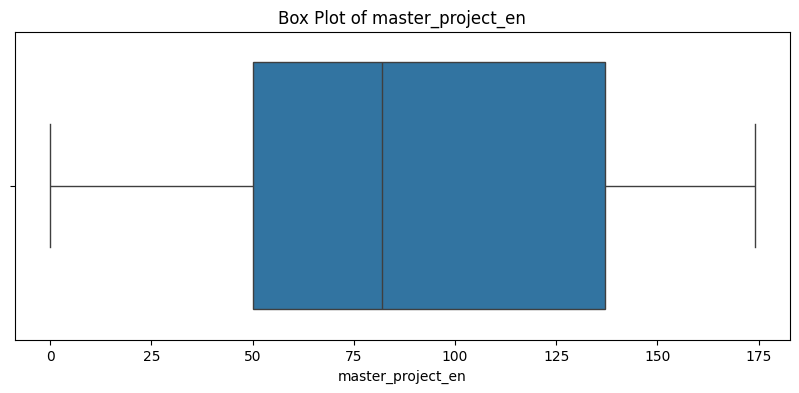

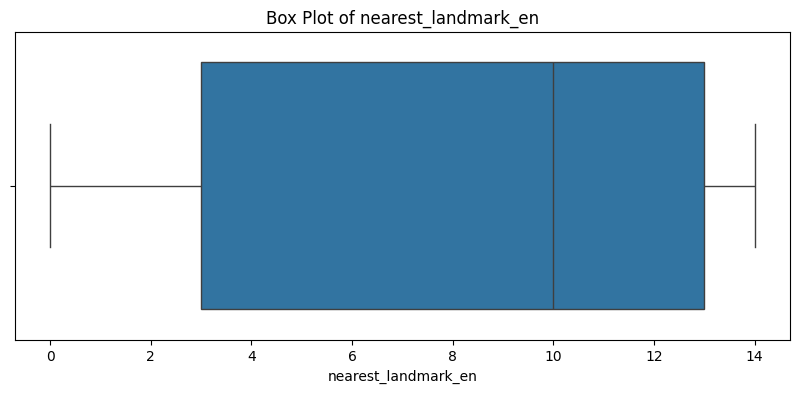

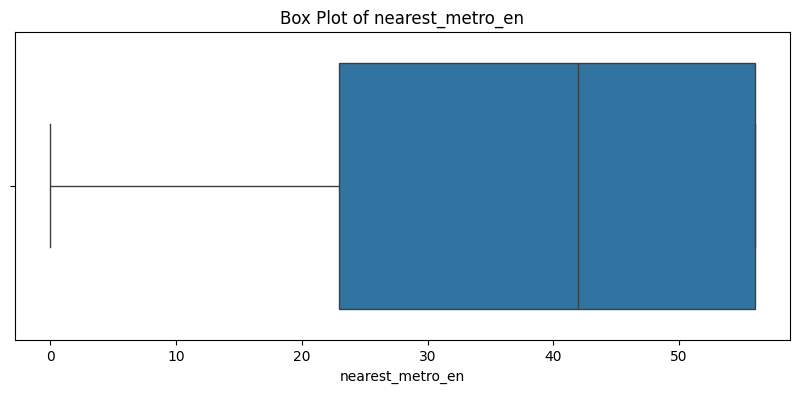

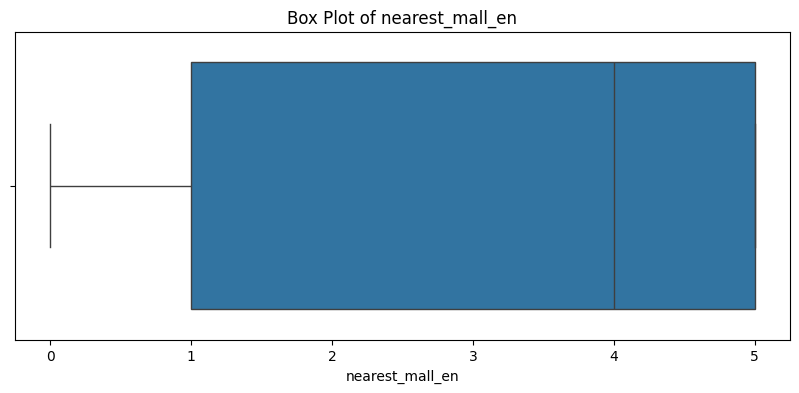

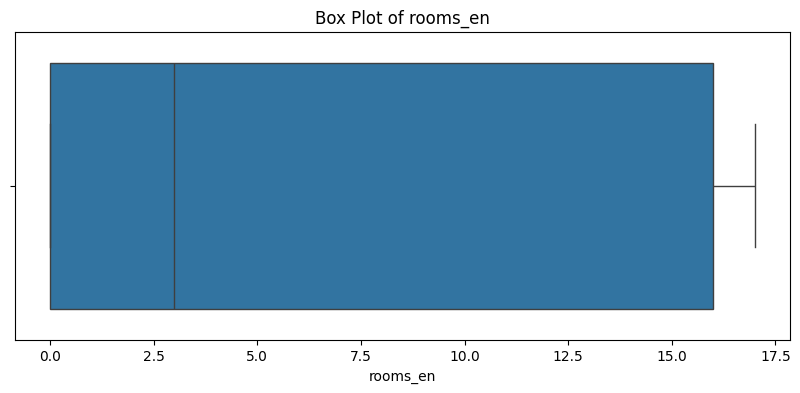

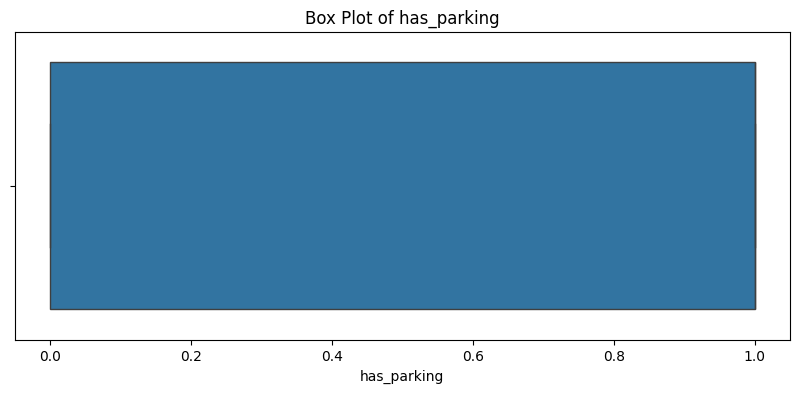

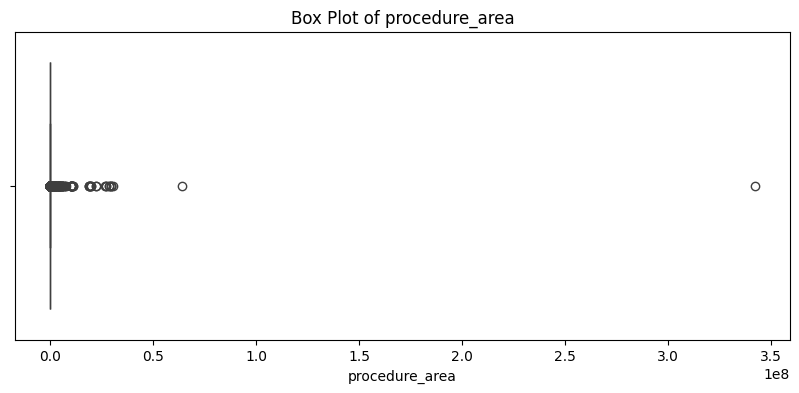

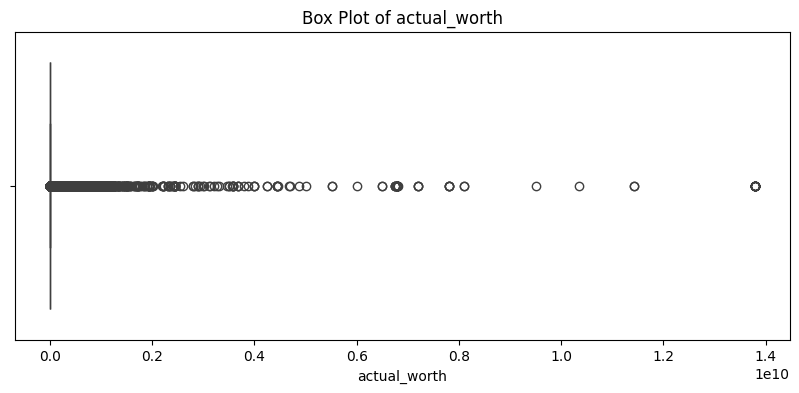

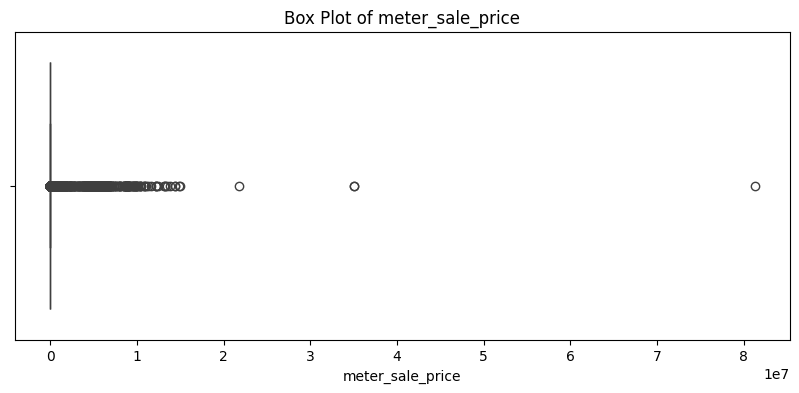

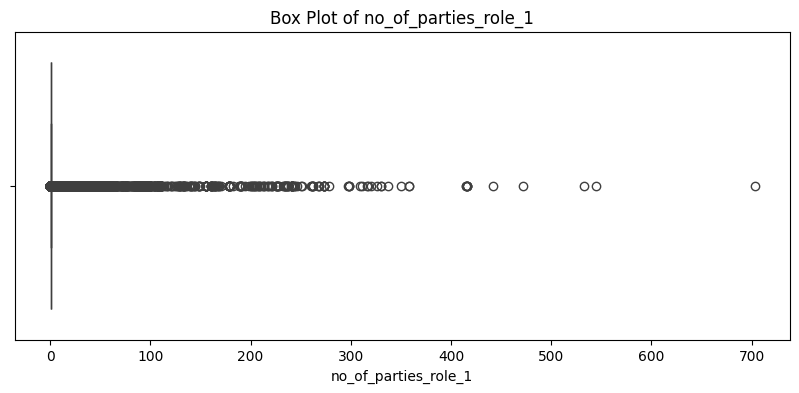

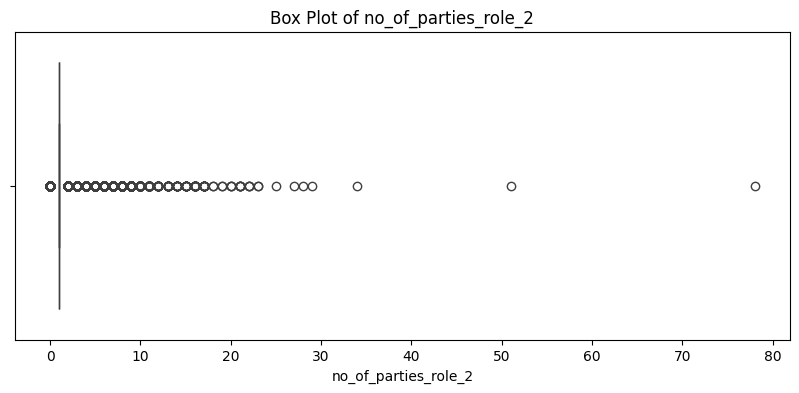

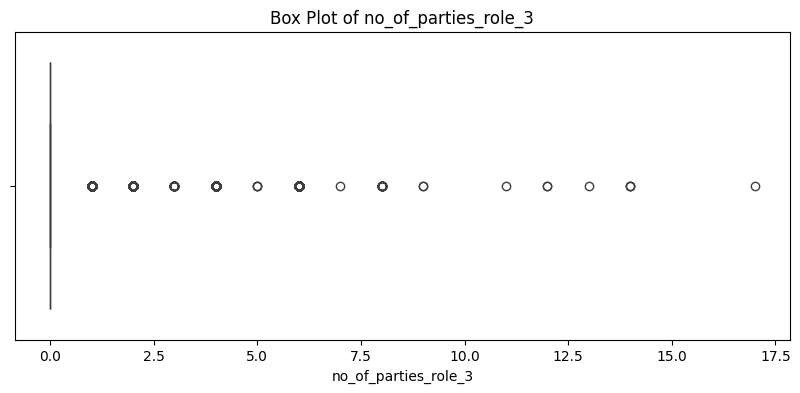

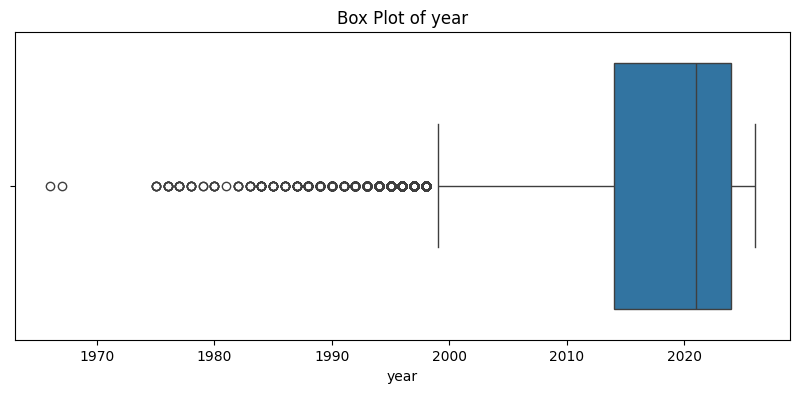

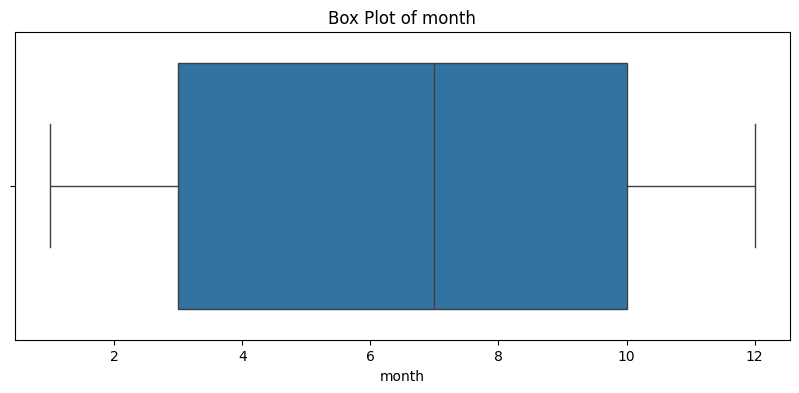

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

### 7. Save Processed Data to CSV

I will now save the currently processed DataFrame to a new CSV file named `transaction_processed.csv` in your Google Drive.

In [15]:
output_file_path = '/content/drive/MyDrive/dataset/transaction_processedb4agg.csv'
df.to_csv(output_file_path, index=False)
print(f"Processed data saved to: {output_file_path}")

Processed data saved to: /content/drive/MyDrive/dataset/transaction_processedb4agg.csv


### 8. Load Processed Data and Perform Aggregation

I will load the `transaction_processed.csv` file and then aggregate the data by `area_id` to calculate the average sale price, transaction count, and a parking score. I will use `meter_sale_price` for average sale price and `has_parking` for parking score.

## District-level aggregation (incl. metro / mall proximity)

For each district we compute the model features. Proximity is built with the simple **1/0-then-average** rule: every transaction record is flagged `1` if it has a known nearby metro / mall (`nearest_metro_en` / `nearest_mall_en` is present, i.e. not null and not `'Unknown'`) and `0` otherwise; the per-district **mean** of those flags is the 0–1 proximity score. (This replaces the earlier invalid approach of averaging label-encoded station names.)

We read the raw export fresh here so the result does not depend on the encoding/null-fill cells above.

In [20]:
# Read the raw transactions fresh (independent of the cells above) for a clean aggregation.
agg_cols = ['area_id','trans_group_en','nearest_metro_en','nearest_mall_en',
            'has_parking','meter_sale_price','actual_worth']

zip_file_path_transactions = '/content/drive/MyDrive/dataset/transactions_raw.csv.zip'
csv_file_in_zip_transactions = 'transactions_2026-04-29_07-47-39_1.csv'

with zipfile.ZipFile(zip_file_path_transactions, 'r') as zf:
    with zf.open(csv_file_in_zip_transactions) as file_handle:
        raw = pd.read_csv(file_handle, usecols=agg_cols)

# Ensure area_id is float before aggregation for consistency
raw['area_id'] = raw['area_id'].astype(float)

# 1/0 proximity flags: 1 if a metro/mall is recorded nearby, else 0
def _known(s):
    return s.notna() & (s.astype(str).str.strip() != '') & (s.astype(str) != 'Unknown')
raw['metro_flag'] = _known(raw['nearest_metro_en']).astype(int)
raw['mall_flag']  = _known(raw['nearest_mall_en']).astype(int)

# total sale value only makes sense for actual sales
raw['sale_worth'] = raw['actual_worth'].where(raw['trans_group_en'] == 'Sales')

aggregated_data = raw.groupby('area_id').agg(
    avg_sale_price    = ('meter_sale_price', 'mean'),   # AED per m^2
    avg_sale_value    = ('sale_worth',       'mean'),   # AED total (sales only) -> used for rental_yield
    transaction_count = ('area_id',          'size'),
    parking_score     = ('has_parking',      'mean'),
    metro_score       = ('metro_flag',       'mean'),   # 0-1 proximity (avg of 1/0 flags)
    mall_score        = ('mall_flag',        'mean')    # 0-1 proximity (avg of 1/0 flags)
).reset_index()

# a few districts have no recorded sales -> median-impute their sale value
aggregated_data['avg_sale_value'] = aggregated_data['avg_sale_value'].fillna(
    aggregated_data['avg_sale_value'].median())

print('districts:', len(aggregated_data))
print(aggregated_data[['area_id','metro_score','mall_score','avg_sale_value']].head())
aggregated_data.head()

districts: 259
   area_id  metro_score  mall_score  avg_sale_value
0    229.0     0.000000    0.000000    2.029900e+06
1    230.0     0.935506    0.000000    1.593337e+06
2    231.0     0.961801    0.156889    1.188933e+07
3    232.0     0.971865    0.971865    2.817807e+06
4    233.0     0.982357    0.524700    2.645607e+06


,area_id,avg_sale_price,avg_sale_value,transaction_count,parking_score,metro_score,mall_score
0,229.0,1326.324301,2.029900e+06,551,0.000000,0.000000,0.000000
1,230.0,5143.045255,1.593337e+06,1473,0.000000,0.935506,0.000000
2,231.0,9686.377121,1.188933e+07,733,0.000000,0.961801,0.156889
3,232.0,7309.106103,2.817807e+06,9952,0.235129,0.971865,0.971865
4,233.0,9927.209538,2.645607e+06,2834,0.000000,0.982357,0.524700


I have aggregated the data for `avg_sale_price`, `transaction_count`, and `parking_score`.

Regarding the `off_plan_score`, I do not have a column in the current dataset that directly corresponds to 'off-plan' status. Could you please specify how you would like me to calculate this score? For example, is there another column that indicates whether a property is 'off-plan' or a way to derive this information from existing features?

### 9. Save Final Aggregated Data to CSV

I will now save the aggregated DataFrame to a new CSV file named `FINAL_TRANSACTION.csv`.

In [21]:
print("Data types of aggregated_data:")
display(aggregated_data.info())

Data types of aggregated_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   area_id            259 non-null    float64
 1   avg_sale_price     259 non-null    float64
 2   avg_sale_value     259 non-null    float64
 3   transaction_count  259 non-null    int64  
 4   parking_score      259 non-null    float64
 5   metro_score        259 non-null    float64
 6   mall_score         259 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 14.3 KB


None

In [22]:
final_output_file_path = '/content/drive/MyDrive/dataset/FINAL_TRANSACTION1.1.csv'
aggregated_data.to_csv(final_output_file_path, index=False)
print(f"Final aggregated data saved to: {final_output_file_path}")

Final aggregated data saved to: /content/drive/MyDrive/dataset/FINAL_TRANSACTION1.1.csv
